In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('youtube_data.csv')
# print(df)

# Red, Blue, Green, Orange, Purple

In [3]:
new_df = df.drop('Video_ID', axis=1)
# print(new_df)

In [4]:
color_df = pd.get_dummies( new_df['Thumbnail_Color'], prefix='Color',  dtype=int)
# print(color_df)

In [5]:
upd_df = pd.concat( [ new_df.drop('Thumbnail_Color', axis=1), color_df ], axis=1 )

# print(upd_df)

In [6]:
upd_df.describe()

,Title_Length,Upload_Hour,Current_Subscribers,Views,Color_Blue,Color_Green,Color_Orange,Color_Purple,Color_Red
count,150.000000,150.000000,150.000000,150.000000,150.00000,150.000000,150.000000,150.000000,150.000000
mean,51.500000,13.413333,36403.666667,11523.886667,0.20000,0.166667,0.133333,0.100000,0.400000
std,19.813476,5.670111,56433.106384,18070.223219,0.40134,0.373927,0.341073,0.301005,0.491539
min,15.000000,1.000000,50.000000,15.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,36.000000,9.250000,2025.000000,605.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,50.000000,15.000000,11750.000000,3550.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,63.750000,18.000000,52000.000000,16425.000000,0.00000,0.000000,0.000000,0.000000,1.000000
max,98.000000,23.000000,320000.000000,105000.000000,1.00000,1.000000,1.000000,1.000000,1.000000


In [7]:

X = upd_df.drop('Views', axis=1)

# print(X)
Y = upd_df['Views']
# print(Y)
# print(X.shape)
# X.describe()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [9]:
model = LinearRegression()
# model.fit(X_train, y_train)
model.fit(X, Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
X_test = [[ 14, 16, 70000, 0, 0, 1, 0, 1]]
y_test = model.predict(X_test)
print(f"Your channel got -> {y_test} views!")

Your channel got -> [22930.77625345] views!


d:\Programming\my_python\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [12]:
accuracy = model.score(X_test, y_test)
print(f"Model accuracy (R^2 Score): {accuracy}")

Model accuracy (R^2 Score): nan


d:\Programming\my_python\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
d:\Programming\my_python\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [13]:
coeficients = pd.DataFrame(model.coef_, X.columns, columns=['Weights'])
print(coeficients)

                        Weights
Title_Length          -9.200200
Upload_Hour           10.615498
Current_Subscribers    0.319455
Color_Blue          -367.555007
Color_Green         -240.271900
Color_Orange          52.590450
Color_Purple         271.950078
Color_Red            283.286379


d:\Programming\my_python\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


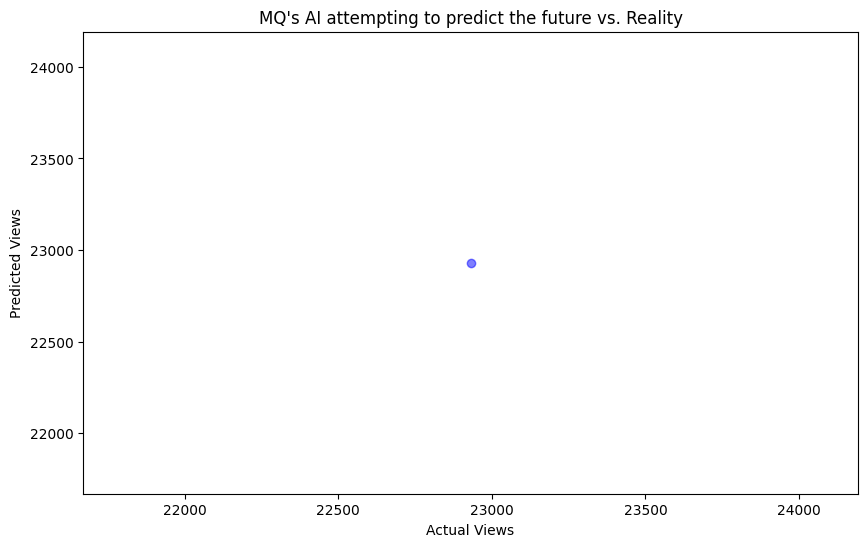

In [14]:

# Plotting the "Reality" vs "Prediction"
plt.figure(figsize=(10, 6))
plt.scatter(y_test, model.predict(X_test), color='blue', alpha=0.5)

# Drawing a perfect line (Where the dots SHOULD be)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)

plt.title('MQ\'s AI attempting to predict the future vs. Reality')
plt.xlabel('Actual Views')
plt.ylabel('Predicted Views')
plt.show()

Read youtube_data.csv | Data cleaning - removed Video_ID column 
| Dropped Thumbnail_Color -> converted each color into separate column ( 0 or 1) | here we go! our first ever prediction | the restult is - According the our model a video of title length 69, uploaded on 13, with 6969 subs chanel, with thumbnail color orange will get -> 1326 views 